# Pulse Planning Example for ITER with TokaMaker_TORAX

v0 2026-05-06 F. Sheehan - File creation

This notebook is an example pulse simulation using TokaMaker and TORAX coupled workflow. TokaMaker is used to solve time-independent equilibria and TORAX solves the 1-D transport equations to evolve the kinetic and current profiles throughout the pulse. Results from the codes are passed back and forth for several loops.

This example should serve as an introduction to the workflow. The inputs are based on Budney et al. 2008 Nuclear Fusion, but are not intended to be exact or in any way an ideal ITER shot.

## Seed eqdsk creation with TokaMaker

The first step is to create initial (AKA seed) equilibria. These are target shapes that are then interpolated between for the first TORAX run.

Notes:
- The first equilibrium's `psi_lcfs` value is critical — it will initialize the TORAX psi target. Following psi values are overwritten after the first TORAX run by its output.
- The shapes of these equilibria will be linearly interpolated between for all TokaMaker_TORAX timepoints. The LCFS geometry targets are never changed or evolved by TokaMaker_TORAX.

This first cell sets global shape targets. In this ITER geometry, the magnetic axis is at Z=0.5 m.

In [1]:
# Global inputs
R0 = 6.3 # m, geometric center of the device
B0 = 5.2 # T, toroidal magnetic field at center of the device
Z0 = 0.5 # m, center of ITER plasma is at +0.5 m on this grid

In [2]:
import sys
sys.path.append('/Users/sameeragrawal/Desktop/CS224R_Project/OpenFUSIONToolkit/install_release/python')

Initialize the OpenFUSIONToolkit (OFT) and TokaMaker objects and setup the mesh using the loaded ITER mesh (`ITER_mesh.h5`).

In [3]:
# OFT setup
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.pulse_design import TokaMaker_TORAX, RLRewardConfig
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun, create_isoflux
import numpy as np
import matplotlib.pyplot as plt
import os
cwd = os.getcwd()

myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('ITER_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.maxits=100
mygs.setup(order = 2, F0 = R0*B0)

mygs.set_coil_vsc({'VS': 1.0})

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           a30f0481
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.859E+02
    # of points  =    4757
    # of edges   =   14156
    # of cells   =    9400
    # of boundary points =     112
    # of boundary edges  =     112
    # of boundary cells  =     112
  Resolution statistics:
    hmin =  9.924E-03
    hrms =  2.826E-01
    hmax =  8.466E-01
  Surface grounded at vertex     870


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    3.

Set up the coil bounds. For this example all poloidal field (PF) and center stack (CS) coils are given $\pm$ 50 MA limits, which are likely much higher than the actual limits. Loose limits are used to prevent the non-convergence of TokaMaker due to coils hitting their limits. These coil limits will also be used for the TokaMaker_TORAX simulation later.

In [4]:
# Set coil bounds
coil_bounds = {key: [-50.E6, 50.E6] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

# function to build regularization terms for coil currents for initial equilibrium solves.
def build_min_norm_coil_reg(mygs):
    """Mild regularization to keep currents reasonable without targeting specific coils."""
    reg_terms = []
    for name in mygs.coil_sets:
        if name.startswith('CS'):
            weight = 2.E-2 if name.startswith('CS1') else 1.E-2
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=weight))
        elif name.startswith('PF'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
        elif name.startswith('VS'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
    reg_terms.append(mygs.coil_reg_term({'#VSC': 1.0}, target=0.0, weight=1.E2))
    mygs.set_coil_reg(reg_terms=reg_terms)

Make initial guesses at the $FF'$ and $p'$ profiles for the initial equilibria. These are not critical because after one loop of TokaMaker_TORAX, these will be overwritten using the kinetic profiles generated by TORAX.

In [5]:
# Make initial FF' and p' profiles for initial equilibria
ffp_prof = create_power_flux_fun(40,1.5,2.0)
pp_prof = create_power_flux_fun(40,4.0,1.0)
mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

Set up lists of targets for the initial equilibria. The lists are iterated through to create the initial equilibria, and eqdsks are saved. 

The five equilibria here is a bare minimum example. Adding more equilibria (and more shapes) can improve the evolution of the pulse. For example, a more careful shape evolution during startup can achieve better results (lower flux consumption, early diversion with desired strike-points). Shape targets produced by these initial equilibria are never evolved/iterated by TokaMaker_TORAX. 

In [6]:
# Make Ip and pax targets
Ip_targets = [1.5e6, 5e6, 15e6, 15e6, 1.5e6]
# pax = pressure on axis
# pax targets calculated from Budney et al. 2008 plots
pax_initial = 2 * 1e19 * 1e3 * 1.602e-19
pax_final = 2 * 1e20 * 12.5e3 * 1.603e-19
pax_targets = [pax_initial, 0.3*pax_initial, pax_final, pax_final, pax_initial]

Note about the `target_psi_lcfs`: The first value in the list (for the `i=0` seed equilibrium) is the most important. This will initialize TORAX for each loop of TokaMaker_TORAX. Currently this value is estimated to be as high as possible with CS currents as close to maximum as possible while still achieving the shape target. 

The other values should reasonable estimates to ensure that the shape targets are achievable within the PF/CS current limits. These values will be overwritten by TORAX after the first loop.

In [7]:
# Set shape targets
a = [1, 2, 2, 2, 1]
kappa = [1, 1.3, 1.8, 1.8, 1]
delta = [0, 0, 0, 0, 0]
diverted = [False, False, True, True, False]
x_points = np.array([[5.125, -3.4],])
diverted_isoflux_pts =np.array([
    [ 8.20,  0.41],
    [ 8.06,  1.46],
    [ 7.51,  2.62],
    [ 6.14,  3.78],
    [5.1   ,  3.72],
    [ 4.51,  3.02],
    [ 4.26,  1.33],
    [ 4.28,  0.08],
    [ 4.49, -1.34],
    [ 7.28, -1.89],
    [ 8.00, -0.68]
])
target_psi_lcfs = [+20, +13, +10, 0, +5] # Wb/rad targets for LCFS flux. Only the first value is used by TORAX, the others are overwritten after the first TORAX run.

The next cell loops through the lists above and produces the initial equilibria, then saves them as `.eqdsk` files to seed TokaMaker_TORAX.

For equilibria that are intended to be limited, the major radius is determined by `R = 3.9 + a[idx]` where 3.9 is the location of the inner limiting surface. No x-point targets are specified, but TokaMaker still sometimes finds diverted equilibria. This can be prevented by reducing the elongation or "pushing" the magnetic axis closer to the limiter surface. 

X-point targets are only applied it the equilibria is supposed to be diverted. `R0` is used for the major radius when diverted (set in the beginning of the notebook). 


/var/folders/n_/52yyfwt914b_ct7mzs001_6h0000gn/T/ipykernel_25069/4242223766.py:24: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(isoflux_pts, targets, weights=weights)


Starting non-linear GS solver
     1  1.6325E+01  8.6335E-03  1.0975E-01  4.9582E+00  4.9992E-01  1.6378E-02
     2  1.9611E+01  4.6929E-03  2.4373E-02  4.9537E+00  4.9995E-01  1.6330E-02
     3  2.0859E+01  4.0118E-03  5.7991E-03  4.9518E+00  4.9996E-01  1.6326E-02
     4  2.1396E+01  3.8137E-03  1.7336E-03  4.9509E+00  4.9997E-01  1.6326E-02
     5  2.1634E+01  3.7436E-03  6.7851E-04  4.9504E+00  4.9998E-01  1.6324E-02
     6  2.1740E+01  3.7162E-03  3.0064E-04  4.9501E+00  4.9998E-01  1.6324E-02
     7  2.1788E+01  3.7049E-03  1.4179E-04  4.9499E+00  4.9998E-01  1.6323E-02
     8  2.1810E+01  3.7001E-03  7.0774E-05  4.9498E+00  4.9998E-01  1.6322E-02
     9  2.1820E+01  3.6980E-03  3.7977E-05  4.9497E+00  4.9998E-01  1.6322E-02
    10  2.1825E+01  3.6971E-03  2.2013E-05  4.9497E+00  4.9998E-01  1.6322E-02
    11  2.1827E+01  3.6966E-03  1.3610E-05  4.9497E+00  4.9998E-01  1.6321E-02
    12  2.1828E+01  3.6965E-03  8.7827E-06  4.9496E+00  4.9998E-01  1.6321E-02
    13  2.1829E+01  3.

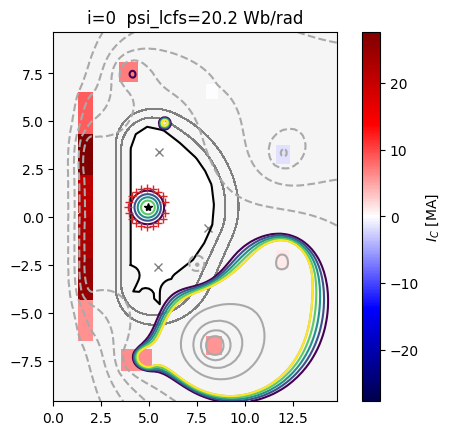

Saving gEQDSK: /Users/sameeragrawal/Desktop/CS224R_Project/OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMaker_TORAX/i=0.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    1.5000E+06
  Current Centroid [m]    =    4.920  0.500
  Magnetic Axis [m]       =    4.950  0.500
  Elongation              =    1.003 (U:  1.003, L:  1.003)
  Triangularity           =   -0.007 (U: -0.008, L: -0.006)
  Plasma Volume [m^3]     =   74.211
  q_0, q_95               =    1.214  3.249
  Plasma Pressure [Pa]    =   Axis:  3.2000E+03, Peak:  3.2000E+03
  Stored Energy [J]       =    1.1552E+05
  <Beta_pol> [%]          =    2.2113
  <Beta_tor> [%]          =    0.0059
  <Beta_n>   [%]          =    0.0228
  Diamagnetic flux [Wb]   =    2.0632E-02
  Toroidal flux [Wb]      =    1.6143E+01
  l_i                     =    1.2403
Starting non-linear GS solver
     1  1.1670E+01  5.9958E-04  1.2946E-01  6.0763E+

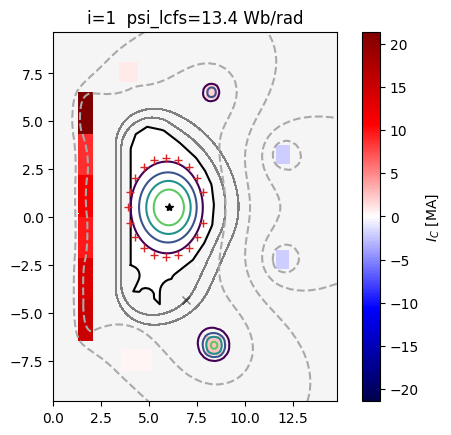

Saving gEQDSK: /Users/sameeragrawal/Desktop/CS224R_Project/OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMaker_TORAX/i=1.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    5.0000E+06
  Current Centroid [m]    =    5.931  0.500
  Magnetic Axis [m]       =    6.053  0.500
  Elongation              =    1.272 (U:  1.272, L:  1.272)
  Triangularity           =   -0.007 (U: -0.008, L: -0.005)
  Plasma Volume [m^3]     =   527.494
  q_0, q_95               =    1.447  4.437
  Plasma Pressure [Pa]    =   Axis:  9.6000E+02, Peak:  9.6000E+02
  Stored Energy [J]       =    2.4246E+05
  <Beta_pol> [%]          =    0.3546
  <Beta_tor> [%]          =    0.0025
  <Beta_n>   [%]          =    0.0052
  Diamagnetic flux [Wb]   =    2.7251E-01
  Toroidal flux [Wb]      =    8.0628E+01
  l_i                     =    1.2434
Starting non-linear GS solver
     1  1.4057E+01  7.5937E-02  3.2817E-01  6.3804E

/var/folders/n_/52yyfwt914b_ct7mzs001_6h0000gn/T/ipykernel_25069/4242223766.py:14: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(diverted_isoflux_pts, targets, weights=weights)


     5  2.3009E+01  4.5467E-02  4.0765E-02  6.3447E+00  5.5452E-01 -6.8559E-04
     6  2.3424E+01  4.4834E-02  2.5394E-02  6.3433E+00  5.5524E-01 -6.4989E-04
     7  2.3676E+01  4.4473E-02  1.5845E-02  6.3426E+00  5.5563E-01 -6.2640E-04
     8  2.3829E+01  4.4261E-02  9.8747E-03  6.3422E+00  5.5583E-01 -6.1142E-04
     9  2.3923E+01  4.4134E-02  6.1399E-03  6.3420E+00  5.5591E-01 -6.0197E-04
    10  2.3981E+01  4.4056E-02  3.8116E-03  6.3418E+00  5.5594E-01 -5.9608E-04
    11  2.4016E+01  4.4009E-02  2.3627E-03  6.3418E+00  5.5594E-01 -5.9244E-04
    12  2.4037E+01  4.3981E-02  1.4652E-03  6.3417E+00  5.5592E-01 -5.9019E-04
    13  2.4051E+01  4.3963E-02  9.0924E-04  6.3417E+00  5.5591E-01 -5.8880E-04
    14  2.4059E+01  4.3952E-02  5.6412E-04  6.3417E+00  5.5590E-01 -5.8794E-04
    15  2.4064E+01  4.3946E-02  3.5016E-04  6.3417E+00  5.5588E-01 -5.8741E-04
    16  2.4067E+01  4.3942E-02  2.1745E-04  6.3417E+00  5.5587E-01 -5.8708E-04
    17  2.4069E+01  4.3939E-02  1.3512E-04  6.3417E+

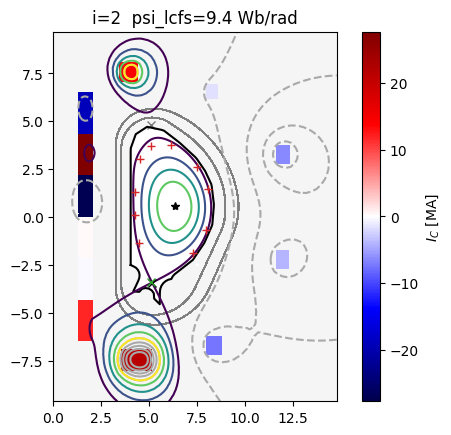

Saving gEQDSK: /Users/sameeragrawal/Desktop/CS224R_Project/OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMaker_TORAX/i=2.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.5000E+07
  Current Centroid [m]    =    6.173  0.562
  Magnetic Axis [m]       =    6.342  0.556
  Elongation              =    1.857 (U:  1.760, L:  1.955)
  Triangularity           =    0.442 (U:  0.366, L:  0.517)
  Plasma Volume [m^3]     =   867.968
  q_0, q_95               =    0.854  3.028
  Plasma Pressure [Pa]    =   Axis:  4.0025E+05, Peak:  4.0025E+05
  Stored Energy [J]       =    1.6327E+08
  <Beta_pol> [%]          =   30.4822
  <Beta_tor> [%]          =    1.1348
  <Beta_n>   [%]          =    0.8114
  Diamagnetic flux [Wb]   =    1.6676E+00
  Toroidal flux [Wb]      =    1.2966E+02
  l_i                     =    1.2029
Starting non-linear GS solver
     1  1.4228E+01  7.6841E-02  3.2804E-01  6.3807

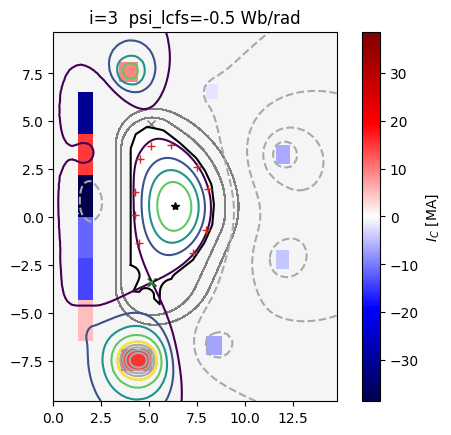

Saving gEQDSK: /Users/sameeragrawal/Desktop/CS224R_Project/OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMaker_TORAX/i=3.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.5000E+07
  Current Centroid [m]    =    6.176  0.556
  Magnetic Axis [m]       =    6.342  0.552
  Elongation              =    1.860 (U:  1.748, L:  1.972)
  Triangularity           =    0.435 (U:  0.352, L:  0.518)
  Plasma Volume [m^3]     =   855.400
  q_0, q_95               =    0.839  2.966
  Plasma Pressure [Pa]    =   Axis:  4.0025E+05, Peak:  4.0025E+05
  Stored Energy [J]       =    1.6090E+08
  <Beta_pol> [%]          =   30.2590
  <Beta_tor> [%]          =    1.1356
  <Beta_n>   [%]          =    0.8065
  Diamagnetic flux [Wb]   =    1.6805E+00
  Toroidal flux [Wb]      =    1.2750E+02
  l_i                     =    1.2138
Starting non-linear GS solver
     1  1.6350E+01  8.6461E-03  8.3261E-02  4.9582

     3  2.0893E+01  4.0120E-03  4.7310E-03  4.9518E+00  4.9995E-01  6.9715E-03
     4  2.1431E+01  3.8136E-03  1.5763E-03  4.9509E+00  4.9996E-01  6.9613E-03
     5  2.1670E+01  3.7436E-03  6.8067E-04  4.9504E+00  4.9996E-01  6.9547E-03
     6  2.1777E+01  3.7162E-03  3.3051E-04  4.9501E+00  4.9996E-01  6.9505E-03
     7  2.1825E+01  3.7049E-03  1.7251E-04  4.9499E+00  4.9996E-01  6.9479E-03
     8  2.1846E+01  3.7000E-03  9.6744E-05  4.9498E+00  4.9997E-01  6.9462E-03
     9  2.1856E+01  3.6979E-03  5.8069E-05  4.9497E+00  4.9997E-01  6.9452E-03
    10  2.1861E+01  3.6970E-03  3.6625E-05  4.9497E+00  4.9997E-01  6.9445E-03
    11  2.1863E+01  3.6966E-03  2.3857E-05  4.9496E+00  4.9997E-01  6.9441E-03
    12  2.1865E+01  3.6964E-03  1.5831E-05  4.9496E+00  4.9997E-01  6.9438E-03
    13  2.1865E+01  3.6963E-03  1.0621E-05  4.9496E+00  4.9997E-01  6.9436E-03
    14  2.1865E+01  3.6963E-03  7.1686E-06  4.9496E+00  4.9997E-01  6.9435E-03
    15  2.1866E+01  3.6962E-03  4.8538E-06  4.9496E+

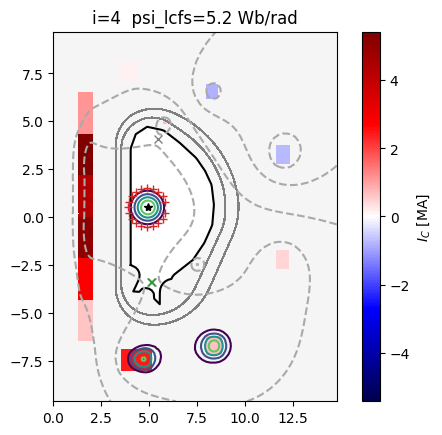

Saving gEQDSK: /Users/sameeragrawal/Desktop/CS224R_Project/OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMaker_TORAX/i=4.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    1.5000E+06
  Current Centroid [m]    =    4.920  0.500
  Magnetic Axis [m]       =    4.950  0.500
  Elongation              =    1.003 (U:  1.002, L:  1.003)
  Triangularity           =   -0.002 (U: -0.005, L:  0.002)
  Plasma Volume [m^3]     =   74.063
  q_0, q_95               =    1.212  3.244
  Plasma Pressure [Pa]    =   Axis:  3.2000E+03, Peak:  3.2000E+03
  Stored Energy [J]       =    1.1533E+05
  <Beta_pol> [%]          =    2.2071
  <Beta_tor> [%]          =    0.0059
  <Beta_n>   [%]          =    0.0228
  Diamagnetic flux [Wb]   =    2.0633E-02
  Toroidal flux [Wb]      =    1.6105E+01
  l_i                     =    1.2396


In [8]:
# Produce initial equilibria
psi_lcfs_results = []

for idx in range(len(a)):
    psi_lcfs_target = target_psi_lcfs[idx]

    if diverted[idx]:  # Flattop (mid-swing)
        R = R0
        mygs.set_saddle_constraints(x_points)
        mygs.set_isoflux_constraints(diverted_isoflux_pts)
        psi_lcfs_weight = 10
        targets = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_flux(diverted_isoflux_pts, targets, weights=weights)
    else:  # Ramp-up/down (pre-charged)
        R = 3.9 + a[idx]
        isoflux_pts = create_isoflux(20, R, Z0, a[idx], kappa[idx], delta[idx])
        mygs.set_isoflux_constraints(isoflux_pts)
        # set_flux_target_on_lcfs(mygs, isoflux_pts, psi_lcfs_target, weight=5.0)
        # build_coil_reg(mygs, cs_precharge_targets) # sets coil targets and regularization depending on phase
        psi_lcfs_weight = 10
        targets = np.full(isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_flux(isoflux_pts, targets, weights=weights)

    build_min_norm_coil_reg(mygs)
    mygs.set_targets(Ip=Ip_targets[idx], pax=pax_targets[idx])

    mygs.init_psi(R, Z0, a[idx], kappa[idx], delta[idx])
    equil_object = mygs.solve()

    stats = mygs.get_stats()
    psi_lcfs = mygs.psi_bounds[0]
    psi_lcfs_results.append(psi_lcfs)
    coil_currents, _ = mygs.get_coil_currents()
    print(f'i={idx}: target psi_lcfs = {psi_lcfs_target:.2f} Wb/rad')
    print(f'      solved psi_lcfs = {psi_lcfs:.2f} Wb/rad  ({psi_lcfs*2*np.pi:.1f} Wb)')

    fig, ax = plt.subplots(1, 1)
    mygs.plot_machine(fig, ax, coil_colormap='seismic', coil_scale=1.E-6,
                      coil_clabel=r'$I_C$ [MA]', coil_symmap=True)
    mygs.plot_psi(fig, ax, plasma_nlevels=5, vacuum_nlevels=5)
    mygs.plot_constraints(fig, ax)
    ax.set_title(f'i={idx}  psi_lcfs={psi_lcfs:.1f} Wb/rad')
    plt.show()

    eqdsk_name = os.path.join(cwd, f'i={idx}.eqdsk')
    mygs.save_eqdsk(eqdsk_name, cocos=2, nr=500, nz=500) # saving at extremely high resolution to avoid issues with contour tracing package used by TORAX, only necessary for initial eqdkss, could possibly be lowered
    mygs.print_info()


## Setup full pulse simulation

The following cells set up the pulse planning simulation. This primarily involves creating the TORAX configuration, which is done with `tmtx.set_*` methods of the `TokaMaker_TORAX` object.

For advanced setups, a complete TORAX configuration (in the form of a dict) can be loaded into TokaMaker_TORAX using the `tmtx.load_TORAX_config` method. This example shows that TORAX can be configured solely with the `tmtx.set_*` methods. 

A few quick notes:
- Time dependent (scalar) inputs should be given in dict form, where the key is the time and the value is the input. Several examples are shown below. TORAX will linearly interpolate between data provided.
- The final time `t_final` for the TokaMaker_TORAX simulation can be smaller than times specified in the configuration. For example if an initial equilibria is set to 600 s, but `t_final` is set to 120 s, the shapes will be interpolated, then the simulation will only be run to 120 s, so this is not a problem. 
- `tm_times` determines the timepoints where TokaMaker_TORAX will produce TokaMaker equilibria during the simulation loop. These can be spaced evenly (as is currently done with `np.linspace`) or unevenly  to generate more equilibria around times of interest (e.g. during rampup). 
- `last_surface_factor` determines how close to the LCFS TORAX will attempt to trace contours when loading the eqdsks. This should be 0.99 or higher. If TokaMaker_TORAX is failing due to eqdsks not being accepted by TORAX, try increasing the resolution (`nr` and `nz` of the `TokaMaker.save_eqdsk` method used to save the initial/seed equilibria above).
- TokaMaker_TORAX requires the user to instantiate and setup the OFT environment and TokaMaker object, then pass the latter to the `TokaMaker_TORAX` object when initializing.

In [9]:

eqdsk_list = [os.path.join(cwd, 'i=0.eqdsk'),  # use initial eqdsk to start
              os.path.join(cwd, 'i=1.eqdsk'),  
              os.path.join(cwd, 'i=2.eqdsk'),  # start of flattop
              os.path.join(cwd, 'i=3.eqdsk'),  # end of flattop
              os.path.join(cwd, 'i=4.eqdsk')]  # use initial eqdsk as end of pulse

eqtimes = [0, 30, 80, 500, 600] # times corresponding to each initial eqdsk


t_final = 600
tmtx = TokaMaker_TORAX(
    t_init = 0,
    t_final = t_final,
    tx_dt = 5, # s, TORAX time step 
    eqtimes = eqtimes,
    g_eqdsk_arr = eqdsk_list,
    last_surface_factor = 0.99,
    tm_times = np.linspace(0, t_final, 10), # the times at which TokaMaker will solve equilibria
    tokamaker_obj = mygs, # passes existing OFT environment to TokaMaker_TORAX
)

`tmtx.set_TORAX_grid` is used to set the radial positions of the TORAX grid, in $\rho_{toroidal}$. This simulation uses uniform grid spacing, 51 points between $\rho_{toroidal} = 0$ and $1$. Non-uniform grid spacing is supported by TORAX and can be used with the `grid_type='face_centers'` and `grid=` specified locations of center of each computational cell.

In [10]:
# Set TORAX Grid, 51 points evenly spaced in rho_toroidal space (TORAX radial coordinate).
tmtx.set_TORAX_grid(grid_type='n_rho', grid=51)

Heating and density sources are specified. Total heating power is split between NBI and ECRH (both of which heat and produce non-inductive current). The $\rho_{tor}$ location of heating deposition is specified, and the TORAX default values for the width of the Gaussian is used. Total heating power estimates for this pulse are based on Budny 2008 NF. The `nbi_current` input tells TokaMaker_TORAX to apply a current source using a ratio of NBI heating power to driven current of 1 W per 16e6 MA. 

Other sources are enabled by default but can be turned off, including fusion power and electron-ion momentum exchange.

Gas puffing is enabled with estimated values. Pellet deposition is also available, by specifying a particle source, a location, and a Gaussian width. Use a time dependent dict for the particle source amount `S_total` to determine when fueling should be applied. Both fueling sources are set using `set_fueling`.

In [11]:
# Heating (Budney 2008 NF: ~33 MW NBI + ~20 MW ECRH at flattop = ~53 MW total)
# ECRH-assisted startup: ECRH on early in current ramp to raise Te, reduce Vloop.

# ECRH: on during ramp-up for assisted startup, continues through flattop and partway into rampdown
ecrh_powers = {
    0:    0,
    10:    0,
    50:   20.0E6,    # ECRH-assisted startup (Budney 2008: ~20 MW during ramp-up)
    80:   20.0E6,    # L-H transition; ECRH stays at 20 MW
    450:  20.0E6,    # End of flattop
    500:  15.0E6,    # Start rampdown
    520:  10.0E6,
    540:   5.0E6,
    560:   0,
    600:   0,
}

# NBI: turns on at L-H transition when plasma is sufficiently dense (Budney 2008: ~33 MW)
generic_powers = {
    0:    0,
    79:   0,
    80:   33.0E6,    # NBI on at L-H transition
    450:  33.0E6,    # End of flattop
    500:  15.0E6,    # Start rampdown
    520:  10.0E6,
    540:   7.0E6,
    560:   4.0E6,
    580:   2.0E6,
    600:   0,
}

tmtx.set_heating(generic_heat=generic_powers, generic_heat_loc=0.25, nbi_current=True, ecrh=ecrh_powers, ecrh_loc=0.35)

tmtx.set_fueling(gas_puff_S_total=1e22, gas_puff_decay_length=0.05, pellet_deposition_location=0.8, pellet_width=0.1, pellet_S_total={0: 0, 90: 5e21, 450: 5e21, 451: 0}) # estimations based on budney2008

This cell produces initial kinetic profiles to pass to TORAX. These are simply to initialize TORAX with reasonable guesses at the density and temperature arrays. These initial profiles will be "relaxed" if the setting is turned on in `fly`, but will strongly affect the initial TORAX plasma conditions.

Pedestal and boundary values are also specified. These are very important because they are not evolved by TORAX or TokaMaker, and are thus used as concrete boundary conditions. When the pedestal is enabled, the pedestal height and location are boundary conditions for the core profiles, and when the pedestal is inactive, the boundary values are used at $\rho_{tor}\approx1$ as boundary conditions. These values affect the core profiles significantly.

There is a method of the `TokaMaker_TORAX` object called `load_pedestal_config` where advanced pedestal configurations can be loaded using TORAX config formatting, if you would like to use a pedestal model other than the default described above.

In [12]:
# Build initial kinetic profiles
n_sample = 25
psi_sample = np.linspace(0.0, 1.0, n_sample)

def array_to_profile_dict(profile_array, psi_grid=None):
    """Convert 1D profile array to TORAX format {psi: value}"""
    if psi_grid is None:
        psi_grid = np.linspace(0.0, 1.0, len(profile_array))
    return {float(psi): float(val) for psi, val in zip(psi_grid, profile_array)}

# Initial L-mode profiles at t=0, will be relaxed during initial relax loop
ne_init = np.array([3.00000000e+19, 2.72795206e+19, 2.48786856e+19, 2.27599203e+19,
       2.08902740e+19, 1.92402147e+19, 1.77840567e+19, 1.64989820e+19,
       1.53648493e+19, 1.43640818e+19, 1.34808146e+19, 1.27014059e+19,
       1.20134100e+19, 1.14064701e+19, 1.08707306e+19, 1.03979586e+19,
       9.98080158e+18, 9.61263085e+18, 9.28769440e+18, 9.00095433e+18,
       8.74788171e+18, 8.52450318e+18, 8.32749199e+18, 8.15354792e+18,
       8.00000000e+18])
Te_init = np.array([1.5       , 1.32687858, 1.17409817, 1.03926765, 0.92029017,
       0.81528639, 0.72262179, 0.64084431, 0.56867223, 0.50498703,
       0.44877911, 0.39918038, 0.35539882, 0.31677537, 0.28268285,
       0.25259736, 0.22605101, 0.20262196, 0.18194419, 0.16369709,
       0.14759247, 0.13337748, 0.1208404 , 0.10977123, 0.1       ])

# Initial profiles only (t=0); evolve=True so TORAX handles time evolution
ne = {0.0: array_to_profile_dict(ne_init, psi_sample)}
Te = {0.0: array_to_profile_dict(Te_init, psi_sample)}

# Initial kinetic profiles and boundary conditions
tmtx.set_ne(ne, right_bc={0: ne_init[-1], 80: 2e19, 500: 2e19, 600: .5e19})
tmtx.set_Te(Te, right_bc=0.1)
tmtx.set_Ti(Te, right_bc=0.1)

# Pedestal heights
ne_ped_val = .9e20   # m^-3
Te_ped_val = 3.0     # keV use for both Te and Ti

ped_toggle = {0: False, 79: False, 80: True, 500: True, 501: False, 600: False}

T_ped = {80: 1.0, 82: 2.0, 90: Te_ped_val, 500: Te_ped_val, 540: 1.0, 580: 1.0, 600: 1.0}
n_e_ped = {80: 3e19, 82: ne_ped_val/2, 90: ne_ped_val, 500: ne_ped_val}

tmtx.set_pedestal(set_pedestal=ped_toggle, T_i_ped=T_ped, T_e_ped=T_ped, n_e_ped=n_e_ped, ped_top=0.9)

This final setup cell sets a few other miscellaneous inputs, including Ip targets, plasma composition, Zeff, evolve settings which tell TORAX which profiles to evolve (defaults are all `True`, i.e. all evolved), and the times the plasma should be diverted (when an X-point target is used in the TokaMaker solve), the location of the X-points, and the constraint weights.

In [13]:
# Misc final setup

tmtx.set_Ip({0: Ip_targets[0], 100: Ip_targets[2], 500: Ip_targets[2], 600: Ip_targets[0]})

# Plasma composition (DT fuel + Ne impurity; Zeff=1.6 sets Ne density)
tmtx.set_plasma_composition(main_ion={'D': 0.5, 'T': 0.5}, impurity='Ne', Zeff=1.6)

tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)

tmtx.set_x_points(diverted_times = (80, 500), x_point_targets = x_points, x_point_weight=100)

tmtx.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=False)

## Run TokaMaker_TORAX

Run the TokaMaker + TORAX simulation for `max_loops` number of loops, where one loop is one full pulse TORAX simulation + `len(times)` TokaMaker solves. There is a convergence check but currently the code just runs for `max_loops`.

`fly` has many options, see the docstring for more details. A minimal example is shown below.

### RL closed-loop (optional)

Set `USE_RL_ACTOR = True` in the next cell to run TORAX with **in-pulse RL heating control** instead of one full-length transport solve. Decisions occur every 20 s from 80–480 s; each decision cold-starts a TORAX rerun from t = 0 with the merged heating schedule accumulated so far.

With **no** `actor_checkpoint`, the default agent applies baseline ECRH/NBI at each knot (same flat-top values as the fixed RL schedule in `pulse_design.py`). This exercises the full closed loop without a trained IQL checkpoint. Pass `actor_checkpoint='path/to/iql_weights.pt'` to use a trained actor instead.

`set_heating()` must still be called with `ecrh_loc` and `generic_heat_loc` (above); RL overrides power schedules during the loop but keeps those source locations.

A few notes:
- This simulation on a relatively new Mac laptop takes about 5 minutes.
- A log file is created in the current working directory that includes some information about the run not printed in the cell output.
- Currently no files (other than the log file) or data are saved by `fly`. If you would like plots/TORAX configs/eqdsk files to be saved there are three options for the `output_mode` input: `False` (or `None`) which outputs nothing except the log file, `minimal`, `normal`, and `debug` which save an increasing number of plots/files. These outputs are saved in the `TokaMaker_TORAX_outputs` folder in the directory in which this notebook is run. Most plots of interest can be made after the fact, see below.
- If `run_name` is left empty or set to `tmp`, any files output (including the log file which is always created) will be overwritten in subsequent runs. If `run_name` is anything but `tmp` then output files will not be overwritten: they are given a unique prefix that includes the `run_name` and a date and time stamp. This includes the log file and any plots/files saved by changing `output_mode`. 
- Flattop averaging is enabled here because `t_ave_toggle='flattop'`. This is intended for sawtooth averaging, and averages the profiles and values passed to TokaMaker over the window specified, only during the flattop period.
- `relax=True` will run short TORAX simulations at the beginning of each loop to allow the input profiles to relax using the new initial equilibrium. `relax_duration` is set for 5 s for the 600 s ITER pulse.
- TokaMaker warning of converge O and X points are nothing to worry about. All the equilibria should solve using L0 (profiles from TORAX without modification). 


In [14]:
# RL closed-loop TORAX heating (see markdown above)
USE_RL_ACTOR = True
ACTOR_CHECKPOINT = 'iql_weights_no_reward_normalization2.pt'  # set to 'path/to/iql_weights.pt' to use a trained IQL actor


In [15]:
tmtx.fly(
    output_mode=False,
    max_loop=2,
    run_name='tmp',
    t_ave_toggle='flattop',
    t_ave_window=25,
    relax=True,
    relax_duration=5,
    use_rl_actor=USE_RL_ACTOR,
    actor_checkpoint=ACTOR_CHECKPOINT,
)

  Log file: /Users/sameeragrawal/Desktop/CS224R_Project/OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMaker_TORAX/TokaMaker_TORAX_log_tmp.log

 TokaMaker_TORAX  
 run_name = tmp | t=[0.0, 600.0] s | 10 timepoints | dt=5 s | max_loop=2 | RL actor (/Users/sameeragrawal/Desktop/CS224R_Project/OpenFUSIONToolkit/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/ITER_TokaMaker_TORAX/iql_weights_no_reward_normalization2.pt)

  Initial TORAX relax


Simulating (t=5.00000): 100%|██████████| 100/100 [00:16<00:00,  5.99it/s]



  Loop 1
  TORAX RL: cold-start t=[0, 80] s (defaults)
  TORAX RL run: t=[0, 80] s (cold-start) ...


Simulating (t=80.00000): 100%|██████████| 100/100 [00:34<00:00,  2.91it/s]


Raw state: [3.43511849e-01 1.07242029e+00 5.75759117e+07 5.00771001e+07
 5.30000000e+07]...
State mean: [6.63281106e-01 2.45190839e+00 2.22358415e+08 7.32485079e+07
 5.16550296e+07]...
State std: [7.10217191e-02 3.28956704e-01 3.88285336e+07 8.14141999e+06
 4.31016379e+06]...
Normalized state: [-4.50241442 -4.1935247  -4.24385079 -2.84611381  0.31204624]...
Sigmoid output: [[0.2061043  0.41564456]]
action_max: [40000000. 33000000.]
Final action: [[8.2441715e+06 1.3716270e+07]]
[8.2441715e+06 1.3716270e+07]
  TORAX RL: cold-start t=[0, 100] s (through next decision)
  TORAX RL run: t=[0, 100] s (cold-start) ...


Simulating (t=81.24145):  81%|████████  | 81/100 [00:38<00:09,  2.09it/s]CONSOLE ERROR: [ERROR] 
          Simulation stopped because ion or electron temperature fell below the
          configured minimum threshold. This is usually caused by radiative
          collapse. Output file contains all profiles up to the last valid step.
          
Simulating (t=81.24145):  81%|████████  | 81/100 [00:38<00:09,  2.09it/s]


  TORAX RL run [0, 100] sim error: SimError.LOW_TEMPERATURE_COLLAPSE


ValueError: TORAX RL run [0, 100] failed: SimError.LOW_TEMPERATURE_COLLAPSE

In [ ]:
import torch

# Load the entire model
model = torch.load('iql_weights_no_reward_normalization.pt', weights_only=False)

# Print the architecture
print(model)

{'actor': OrderedDict({'net.0.weight': tensor([[-0.0619,  0.0626, -0.1058,  ...,  0.1619, -0.1380, -0.0779],
        [-0.0667, -0.0710, -0.1290,  ...,  0.0995,  0.1563, -0.1045],
        [ 0.1352, -0.0288, -0.0035,  ..., -0.0168,  0.0346, -0.1550],
        ...,
        [-0.0209,  0.0153,  0.1004,  ...,  0.1329, -0.1326, -0.1192],
        [ 0.1553,  0.1171, -0.0110,  ...,  0.1120,  0.1267,  0.1014],
        [ 0.0924, -0.0824, -0.1179,  ...,  0.0753,  0.0643,  0.1733]]), 'net.0.bias': tensor([-0.0455,  0.1084,  0.1073, -0.0827,  0.1858,  0.1476,  0.1797,  0.0510,
         0.1401, -0.1157,  0.0196, -0.0224, -0.0266, -0.0545, -0.0170,  0.1349,
         0.0261,  0.0371,  0.1435,  0.0783, -0.0455,  0.1389,  0.0824,  0.1359,
         0.0081,  0.0187,  0.1235,  0.0006,  0.1127, -0.1002,  0.0370,  0.1755,
        -0.1143,  0.0795,  0.1667,  0.0477,  0.0878,  0.1250,  0.1642,  0.0784,
         0.1318,  0.1074,  0.0336,  0.1469,  0.0933, -0.0109,  0.0709,  0.0767,
         0.0459,  0.1141,  0.043

In [ ]:
print(model['actor'].keys())

odict_keys(['net.0.weight', 'net.0.bias', 'net.2.weight', 'net.2.bias', 'net.4.weight', 'net.4.bias'])


In [ ]:
# Quick check that the RL closed loop ran (baseline agent when ACTOR_CHECKPOINT is None)
if USE_RL_ACTOR:
    history = getattr(tmtx, '_rl_actions_history', [])
    print(f'RL heating decisions: {len(history)}')
    for row in history:
        print(row)


RL heating decisions: 21
{'decision_t': 80.0, 'knot_t': 100.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 100.0, 'knot_t': 120.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 120.0, 'knot_t': 140.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 140.0, 'knot_t': 160.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 160.0, 'knot_t': 180.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 180.0, 'knot_t': 200.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 200.0, 'knot_t': 220.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 220.0, 'knot_t': 240.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 240.0, 'knot_t': 260.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 260.0, 'knot_t': 280.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 280.0, 'knot_t': 300.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 300.0, 'knot_t': 320.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 320.0, 'knot_t': 340.0, 'ecrh_MW': 0.0, 'nbi_MW': 0.0}
{'decision_t': 340.0, 'knot_t': 360.0, 'ecrh_MW': 0.0, 'nbi_MW': 0

In [ ]:
cfg = RLRewardConfig(
    # ── Safety thresholds ──────────────────────────────
    q95_min               = 3.0,   # q95 must stay above this
    beta_n_max            = 2.8,   # beta_N must stay below this
    fgw_max               = 0.85,  # Greenwald fraction must stay below this

    # ── Step reward ────────────────────────────────────
    step_reward_weight    = 1.0,   # weight on log(mean_Q_fusion + 1) per interval

    # ── Safety penalty weights ─────────────────────────
    q95_penalty_weight    = 0.15,  # per unit of q95 violation summed over interval
    beta_n_penalty_weight = 1.67,  # per unit of beta_N violation summed over interval
    fgw_penalty_weight    = 3.0,   # per unit of fgw violation summed over interval

    # ── Terminal bonus ─────────────────────────────────
    q_flattop_weight      = 1.0,   # weight on Q_flattop_avg at end of pulse
    flux_weight           = 0.001, # penalty per Wb of flux consumed
)

rewards = tmtx.compute_rewards(cfg)
print(f"Total reward: {sum(rewards):.4f}")
print(f"Per-step rewards: {rewards}")

Total reward: 35.4898
Per-step rewards: [np.float64(1.9303534086652145), np.float64(2.9586357657301767), np.float64(0.09006590060807529), np.float64(-0.6563680817310131), np.float64(-1.3893771728457849), np.float64(-1.3150282656263914), np.float64(-1.652190266485634), np.float64(-1.6927102477236535), np.float64(-1.7086061413837093), np.float64(-1.7159222207237481), np.float64(-1.44007052093577), np.float64(-1.686936915490965), np.float64(-1.6634206554036113), np.float64(-1.6374740131216452), np.float64(-1.6116795030229514), np.float64(-1.5880228515004573), np.float64(-1.5588550267895016), np.float64(-1.2698965334676564), np.float64(0.04183065299900601), np.float64(3.4153755364542087), np.float64(49.64012034794048)]


## Plot results

Plots are created with built-in methods of the `TokaMaker_TORAX` object. If called in a Jupyter notebook the plots are simply displayed. If called in a `.py` script that will also appear and must be closed for the script to continue. They all have `save_path` arguments, and if you don't want them displayed they can be silently saved by setting `display=False`. 

`plot_scalars` plots many scalar quantities over the course of the pulse. TORAX values are plotted at their full time resolution; TokaMaker outputs are plotted at the `tm_times`, i.e. the times at which TokaMaker is solved.

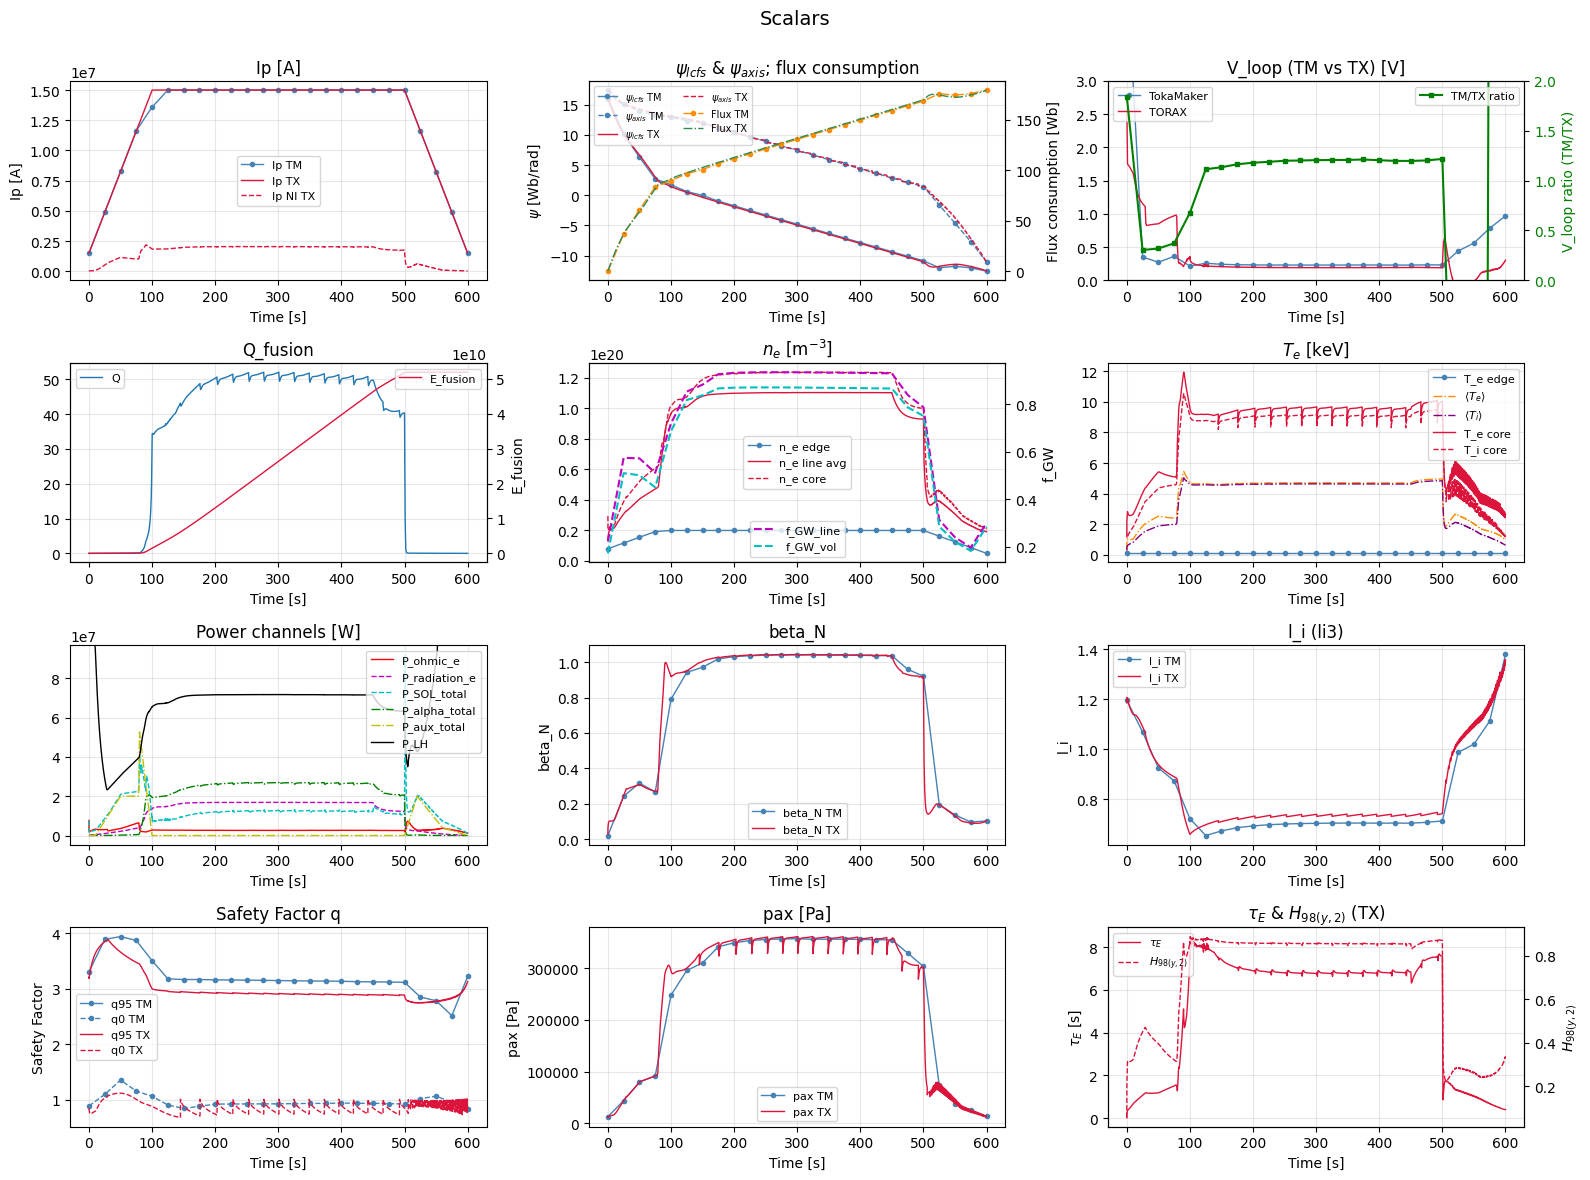

In [ ]:
tmtx.plot_scalars()

The `make_movie` method produces a `.mp4` with one frame per TokaMaker solve time. The `speed_factor` input (default `1`) changes the playback speed relative to realtime, higher `speed_factor` will make the movie shorter, smaller will make the movie longer, `speed_factor=1` will make the movie take realtime, or 1 frame/equilibria per second, whichever is faster.

In [ ]:
tmtx.make_movie(notebook_mode=True, speed_factor=10)

In [ ]:
_ = tmtx.summary()


  TokaMaker_TORAX Physics Summary
  Q_max                           52.05
  Q_max_time                      277
  Q_flattop_avg                   46.46
  E_fusion_total_MJ               5.192e+04
  beta_N_max                      1.043
  H98_max                         0.8893
  H98_flattop_avg                 0.8621
  T_e_core_max_keV                11.94
  T_i_core_max_keV                10.54
  n_e_line_avg_max                1.103e+20
  f_GW_max                        0.9357
  q95_min                         2.515
  q0_min                          0.8242
  flux_consumed_Wb                179.6
  P_fusion_max_MW                 135.2
  P_ohmic_max_MW                  7.651
  l_i_flattop_avg                 0.6997
  vloop_tx_flattop_avg_V          0.2022



The evolution plots, `plot_lcfs_evolution` and `plot_profile_evolution`, show traces at different times throughout the pulse where color encodes time. Both have a `one_plot` argument (default `False`) that combines all phases into one figure. When `one_plot=False` a separate plot is produced for each phase of the pulse (ramp-up, flattop, ramp-down), or whichever subset occurs in the simulation.

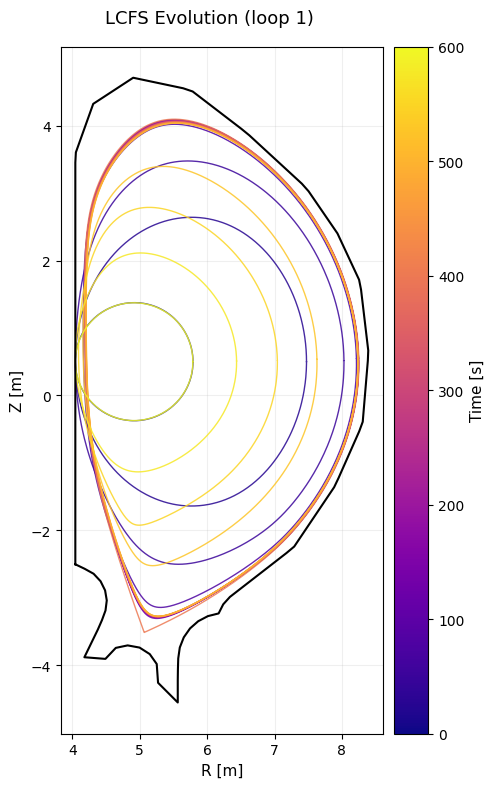

In [ ]:
tmtx.plot_lcfs_evolution(one_plot=True)

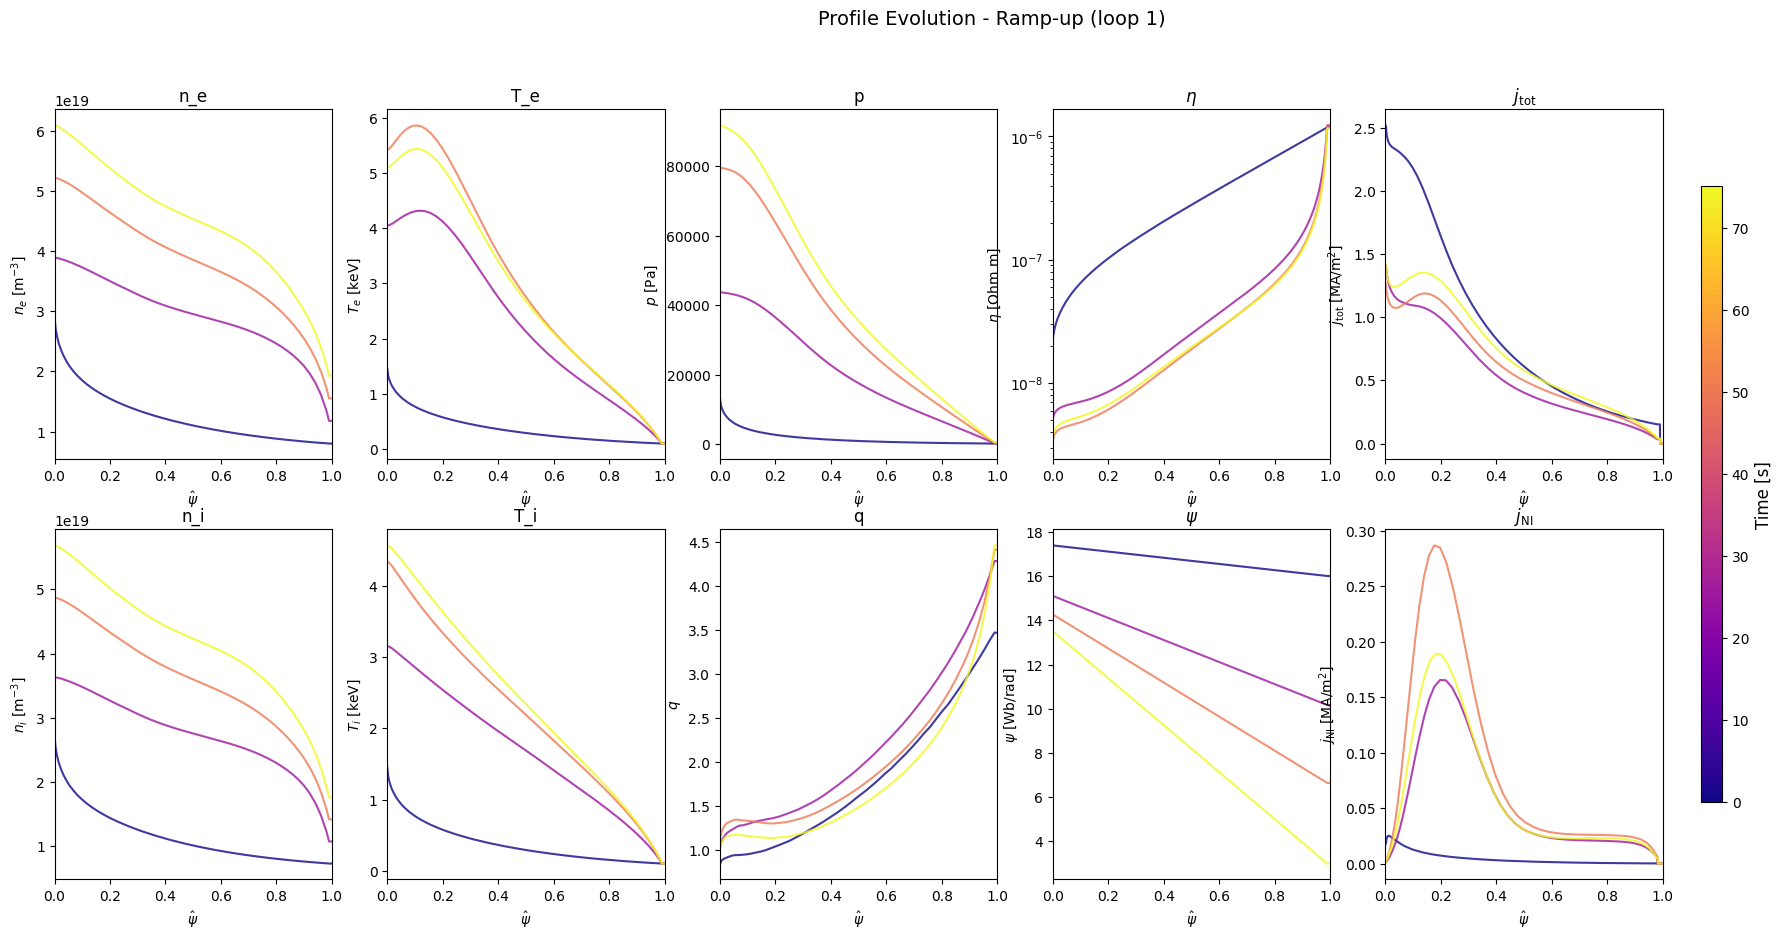

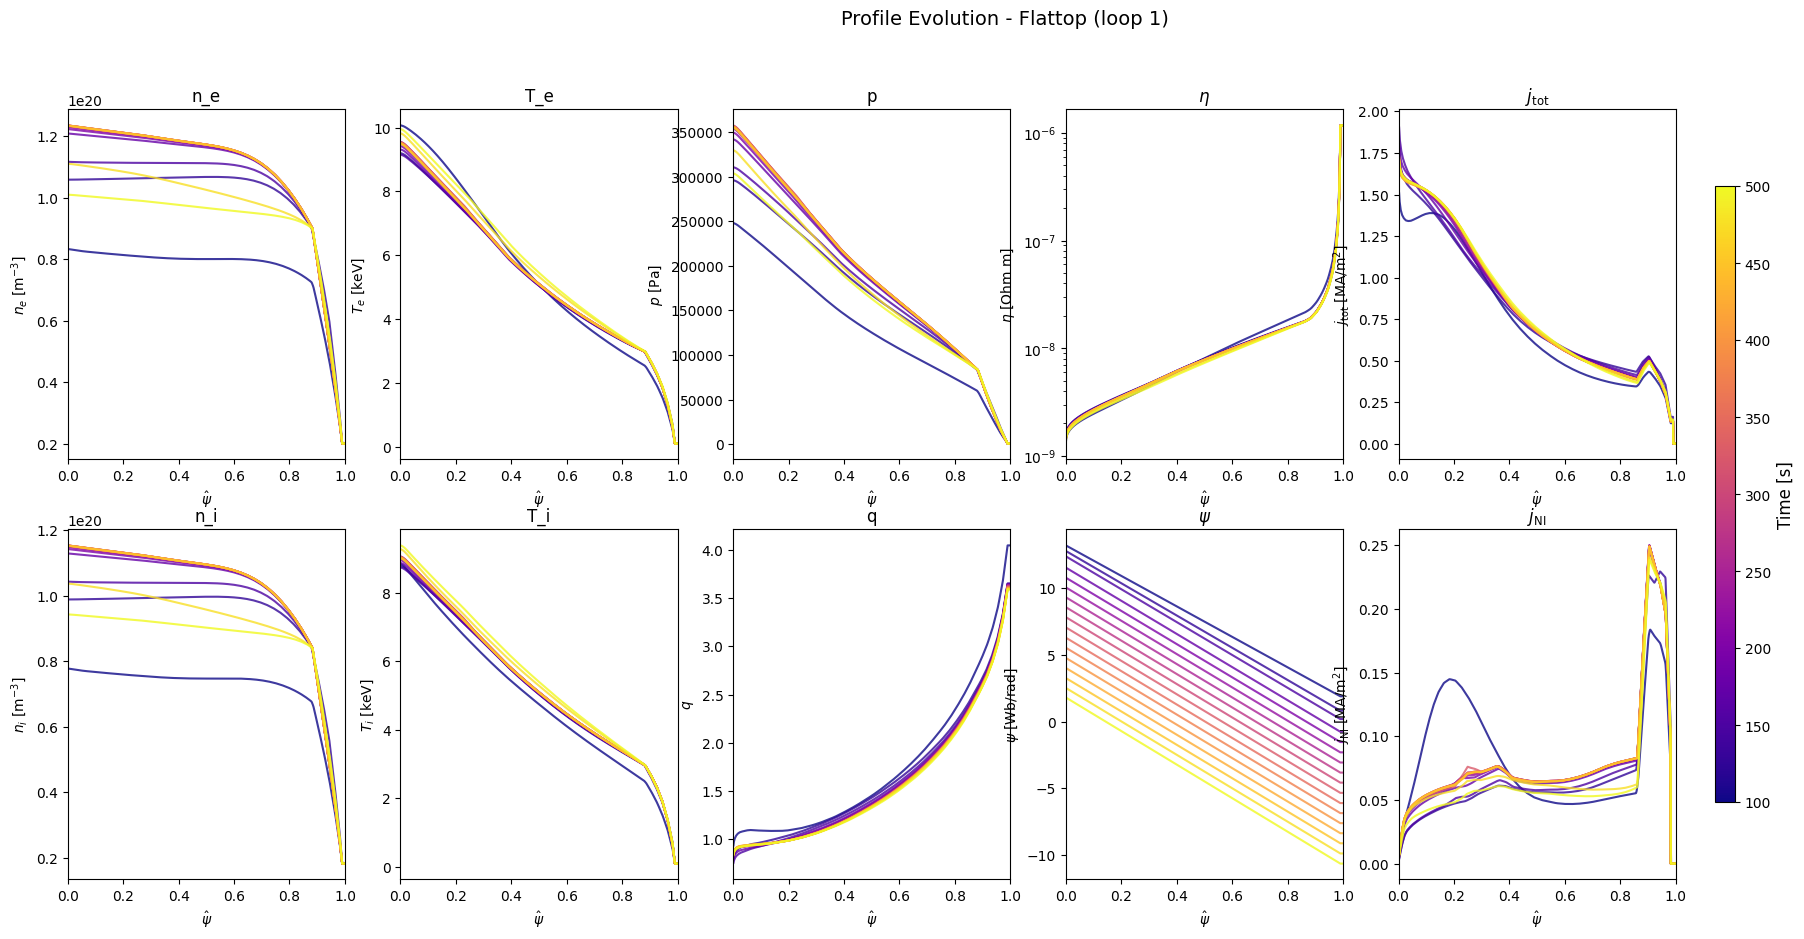

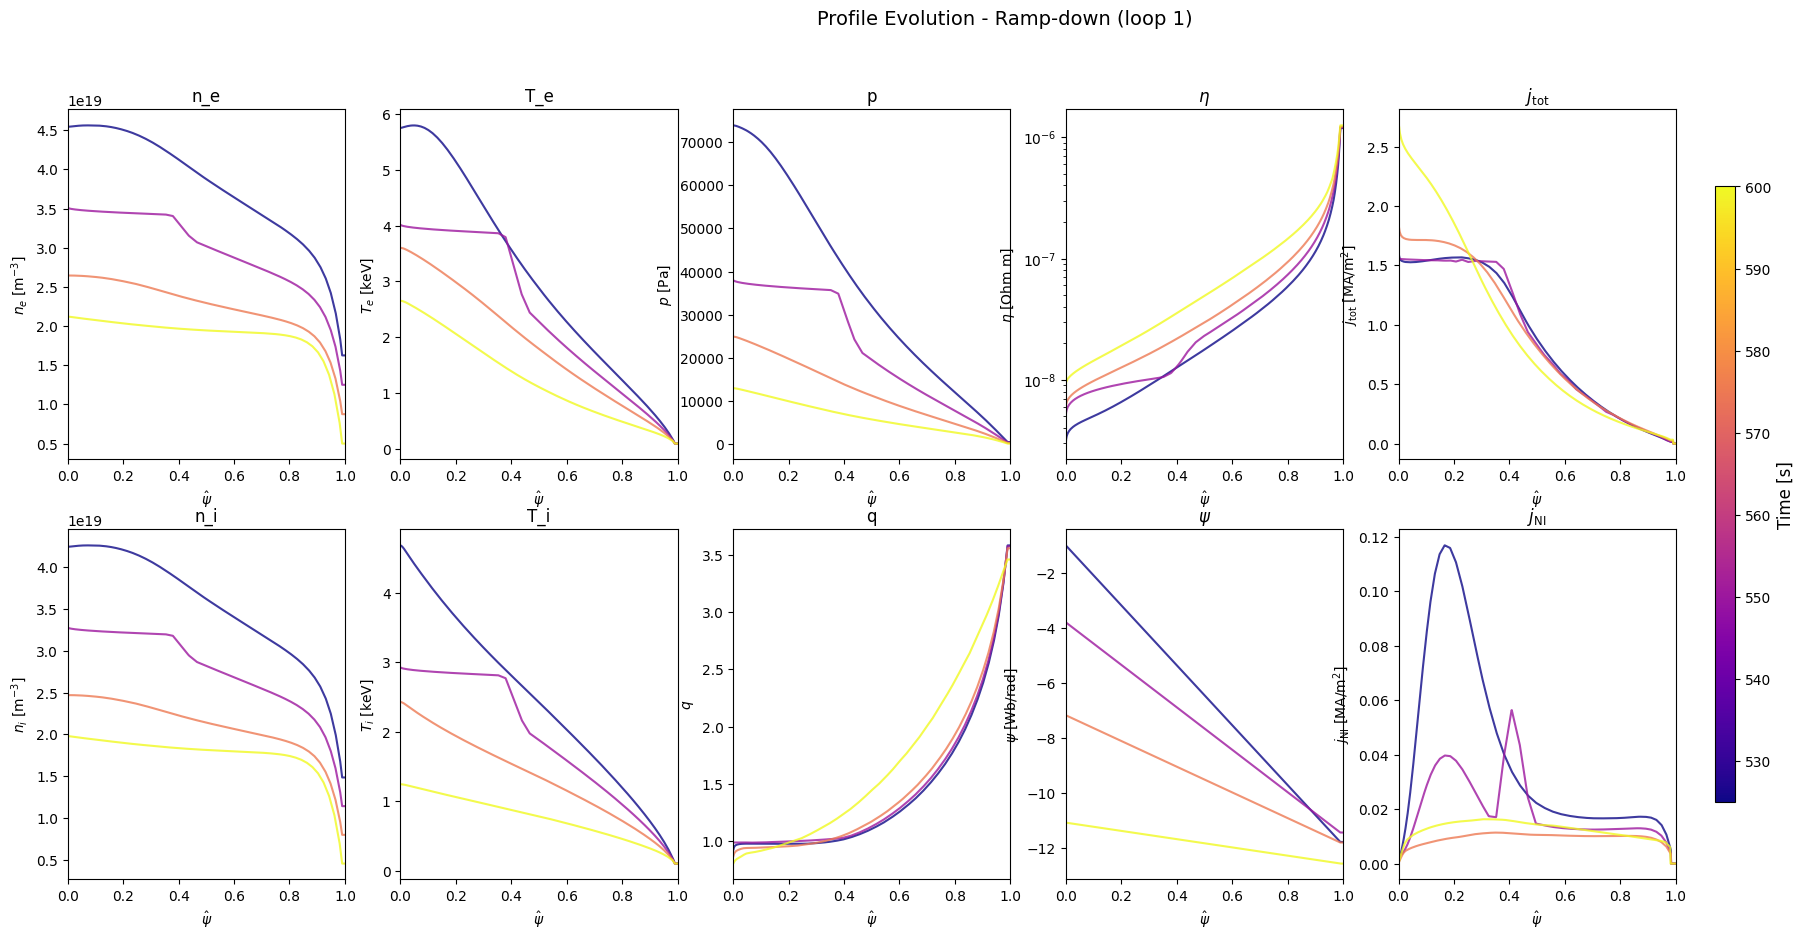

In [ ]:
tmtx.plot_profile_evolution()